Ensemble
===

**Autor:** Mateus de Jesus Mendes

# Introdução

Este *Jupyter Notebook* tem por objetivo implementar um *ensmble* composto pelos modelos previamente treinados (ElasticNet, $k$-NN, SGD, SVR e XGBoost) para induzir um modelo final a partir dos elementos do *dataset* `xtb_dataset.csv`.

## Fundamentação Teórica

O *Stacking* (***Stacked Generalization***) é um método de ensemble proposto por David H. Wolpert ($1992$) que busca reduzir o viés e a variância de modelos preditivos combinando-os de forma hierárquica.

Diferentemente de abordagens como o *Bagging* ou o *Voting*, que simplesmente agregam as previsões por média ou votação, o *Stacking* utiliza um modelo de nível meta (*meta-learner*) que aprende a combinar as previsões dos modelos base de maneira otimizada.

O processo ocorre em duas etapas principais: primeiro, diversos modelos de primeira camada (ou *base learners*) são treinados sobre o mesmo conjunto de dados. Em seguida, suas previsões são reunidas e usadas como novas variáveis de entrada para o modelo de segunda camada (*final estimator*), responsável por produzir a predição final.

Para evitar sobreajuste, o treinamento do meta-modelo é feito a partir de previsões obtidas por validação cruzada — isto é, cada modelo base prevê valores para subconjuntos de dados que não foram usados em seu ajuste. Essa estratégia garante que o estimador final aprenda padrões generalizáveis em vez de apenas replicar os erros dos modelos base.

Na biblioteca `scikit-learn`, o estimador `StackingRegressor` implementa esse procedimento de forma automatizada. Ele utiliza internamente a função `cross_val_predict` para gerar as previsões fora da amostra durante a fase de treinamento, de acordo com o parâmetro `cv` definido pelo usuário. Assim, o meta-estimador é treinado sobre previsões obtidas de maneira justa e independente, assegurando um processo de *stacking* estatisticamente consistente.

Em suma, o *Stacking* não se limita a combinar modelos — ele aprende a melhor maneira de fazê-lo, integrando diferentes perspectivas de modelagem e explorando a complementaridade entre algoritmos para alcançar previsões mais robustas e precisas.

# Metodologia

### Importações

In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import Ridge, ElasticNet, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.metrics import root_mean_squared_error

import optuna
from optuna import load_study

import joblib

import shap

### Definições Globais

Definições de parâmetros globais usados ao longo desse *Jupyter Notebook*, a fim de assegurar clareza metodológica e reprodutibilidade:

In [2]:
RANDOM_SEED = 88
PATH = '../../dataset_processing/xtb_dataset.csv'
TRAIN_SIZE = 0.8
STUDY_NAME = 'ensemble'

### Leitura dos Dados

Leitura do *dataset*:

In [3]:
df = pd.read_csv(PATH)

X = df.drop(columns=['Delta'])
y = df['Delta']

In [4]:
X

,Dipole,E_HOMO,E_LUMO,gap_HOMO-LUMO,ZPE,H,U,U0,G
0,0.727,-10.6203,-2.7950,-7.8253,0.154214,-27.917739,-27.918683,-28.080950,-27.959630
1,1.905,-10.4336,-2.2949,-8.1387,0.199866,-28.104404,-28.105348,-28.313524,-28.146070
2,4.475,-10.5746,-6.9494,-3.6252,0.120064,-27.272560,-27.273504,-27.400818,-27.312535
3,2.100,-9.8173,-5.5314,-4.2859,0.177677,-27.068399,-27.069343,-27.254803,-27.108720
4,0.872,-9.9722,-6.6172,-3.3550,0.133244,-24.148876,-24.149821,-24.292155,-24.192788
...,...,...,...,...,...,...,...,...,...
129152,4.710,-11.3840,-7.8335,-3.5505,0.121817,-26.808903,-26.809847,-26.939965,-26.851229
129153,4.996,-10.8793,-7.1097,-3.7696,0.141742,-28.278349,-28.279293,-28.428099,-28.317523
129154,3.973,-10.9497,-7.7346,-3.2151,0.124894,-24.819326,-24.820270,-24.952019,-24.858199
129155,0.918,-10.2869,-1.8611,-8.4258,0.195977,-30.002576,-30.003520,-30.208931,-30.047056


### Pré-processamento dos Dados

Divisão do *dataset* em subconjuntos de dados de treino e teste, considerando as *features* e o *target*:

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SIZE, random_state=RANDOM_SEED)

### Treino & Otimização de Hiperparâmetros

Definição dos modelos base:

In [6]:
# ElasticNet
best_model_en = make_pipeline(
    StandardScaler(),
    VarianceThreshold(0.04137779740016238),
    ElasticNet(alpha=4.742486275093751e-05,
               l1_ratio=0.018589191548930475,
               fit_intercept=True,
               positive=False,
               max_iter=41963,
               tol=6.982053770448695e-07,
               selection='random'))

# kNN
best_model_knn = make_pipeline(
    StandardScaler(), 
    KNeighborsRegressor(n_neighbors=4,
                        weights='distance',
                        metric='manhattan'))

# SGD
best_model_sgd = make_pipeline(
    StandardScaler(),
    VarianceThreshold(0.0003095313058332159),
    SGDRegressor(loss='squared_error',
                 penalty='l2',
                 alpha=6.2269177801281935e-06,
                 learning_rate='adaptive',
                 eta0=0.0644834328258094))

# SVR
# Modelo SVR com os melhores parâmetros
best_model_svr = make_pipeline(
    StandardScaler(),
    SVR(kernel='linear',
        C=13.978181360804484,
        epsilon=0.010033199456911295))

best_model_xgb = XGBRegressor(booster='gbtree',
                              learning_rate=0.021284051324216856,
                              n_estimators=1930,
                              subsample=0.7577937243056768,
                              colsample_bytree=0.8379115844846744,
                              colsample_bylevel=0.636877116450914,
                              colsample_bynode=0.8794677006047796,
                              min_child_weight=0.002797687917122989,
                              gamma=1.701085854648532e-07,
                              reg_alpha=4.3309175266571056e-08,
                              reg_lambda=0.0006700533858310995,
                              max_delta_step=8,
                              grow_policy='depthwise',
                              max_depth=7,
)

base_models = {
    "elasticnet": best_model_en,
    "knn": best_model_knn,
    "sgd": best_model_sgd,
    "svr": best_model_svr,
    "xgb": best_model_xgb
}

Função objetivo do `optuna`:

In [7]:
def objective(trial, X, y):

    ensemble_type = trial.suggest_categorical(
        "ensemble_type", ["voting", "stacking"]
    )


    # VOTING REGRESSOR
    if ensemble_type == "voting":

        voting_strategy = trial.suggest_categorical(
            "voting_strategy", ["hard", "soft"]
        )

        selected_models = []
        weights = []

        for name, model in base_models.items():
            use_model = trial.suggest_categorical(f"use_{name}", [0, 1])
            if use_model:
                selected_models.append((name, model))
                if voting_strategy == "soft":
                    weights.append(
                        trial.suggest_float(f"w_{name}", 0.1, 5.0)
                    )

        if len(selected_models) < 2:
            raise optuna.exceptions.TrialPruned()

        if voting_strategy == "hard":
            ensemble = VotingRegressor(
                estimators=selected_models
            )
        else:
            ensemble = VotingRegressor(
                estimators=selected_models,
                weights=weights
            )


    # STACKING REGRESSOR
    else:
        selected_models = []

        for name, model in base_models.items():
            use_model = trial.suggest_categorical(f"use_{name}", [0, 1])
            if use_model:
                selected_models.append((name, model))

        if len(selected_models) < 2:
            raise optuna.exceptions.TrialPruned()

        meta_model_name = trial.suggest_categorical(
            "meta_model", ["ridge", "elasticnet"]
        )

        if meta_model_name == "ridge":
            meta_model = Ridge(
                alpha=trial.suggest_float("meta_alpha", 1e-3, 10, log=True)
            )
        else:
            meta_model = ElasticNet(
                alpha=trial.suggest_float("meta_alpha", 1e-4, 1e-1, log=True),
                l1_ratio=trial.suggest_float("meta_l1_ratio", 0.0, 1.0)
            )

        ensemble = StackingRegressor(
            estimators=selected_models,
            final_estimator=meta_model,
            passthrough=False,
            n_jobs=-1
        )


    # AVALIAÇÃO
    score = cross_val_score(
        ensemble,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1
    ).mean()

    return -score


Execução dos estudos de otimização de hiperparâmetros do `optuna`:

> **📌 Observação:** O seguinte código está comentado como célula Markdown por apresentar elevado custo computacional. Desse modo, é recomendada execução do *script* `Ensemble.py` utilizando computação de alto desempenho (HPC) a fim de garantir eficiência e estabilidade computacional na execução dos estudos de otimização. Após isso, basta mover o arquivo `ensemble.db` para o mesmo diretório desse *Jupyter Notebook* e executar as células seguintes.

---
```python
study = optuna.create_study(
    direction="minimize",
    study_name=STUDY_NAME
)

study.optimize(
    lambda trial: objective(trial, X, y),
    n_trials=300,
    n_jobs=1
)
```
---

Acesso aos estudos de otimização, para extração dos melhores valores dos hiperparâmetros e o desempenho obtido:

In [8]:
study = load_study(
    study_name=STUDY_NAME,
    storage=f'sqlite:///{STUDY_NAME}.db'
)

Melhores hiperparâmetros obtidos durante a otimização:

In [9]:
best_trial = study.best_trial
params = best_trial.params

Desempenho do melhor modelo obtido:

In [10]:
best_trial.value

0.00014316652399008913

Função para reconstrução determinística:

In [ ]:
def build_best_ensemble(params):

    if params["ensemble_type"] == "voting":
        selected_models = []
        weights = []

        for name, model in base_models.items():
            if params.get(f"use_{name}", 0):
                selected_models.append((name, model))
                if params["voting_strategy"] == "soft":
                    weights.append(params[f"w_{name}"])

        if params["voting_strategy"] == "hard":
            return VotingRegressor(estimators=selected_models)
        else:
            return VotingRegressor(
                estimators=selected_models,
                weights=weights
            )

    else:
        selected_models = []

        for name, model in base_models.items():
            if params.get(f"use_{name}", 0):
                selected_models.append((name, model))

        if params["meta_model"] == "ridge":
            meta = Ridge(alpha=params["meta_alpha"])
        else:
            meta = ElasticNet(
                alpha=params["meta_alpha"],
                l1_ratio=params["meta_l1_ratio"]
            )

        return StackingRegressor(
            estimators=selected_models,
            final_estimator=meta,
            passthrough=False,
            n_jobs=-1
        )

Treino final e exportação:

In [12]:
best_ensemble = build_best_ensemble(best_trial.params)

best_ensemble.fit(X, y)

joblib.dump(best_ensemble, "model.pkl")
joblib.dump(list(X.columns), "columns_ref.pkl")

['columns_ref.pkl']

### Teste

Treino e teste finais para avaliação do melhor modelo obtido:

In [16]:
y_pred = best_ensemble.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)

print(f'RMSE do melhor modelo: {rmse}')

RMSE do melhor modelo: 0.0002063070613966953


# Resultados

O melhor modelo induzido a partir das otimizações de hiperparâmetro do `optuna` foi um *ensemble* do tipo *stacking* que tem por *base-learners* os algoritmos ElasticNet, $k$-NN e SGD e utiliza o algoritmo Ridge enquanto *meta-learner*. Esse modelo obteve $\mathrm{RMSE}$ de $\approx 0.0001$, dotado do seguintes hiperparâmetros e métodos de pré-processamento dos dados indicado na estrutura do `scikit-learn`:

In [25]:
best_ensemble

,estimators,"[('elasticnet', ...), ('knn', ...), ...]"
,final_estimator,Ridge(alpha=0...8941112340723)
,cv,None
,n_jobs,-1
,passthrough,False
,verbose,0
,copy,True
,with_mean,True
,with_std,True
,threshold,0.04137779740016238
,alpha,4.742486275093751e-05


Por fim, ao desenvolver o teste final, o modelo induzido com os hiperparâmetros supracitados obteve $\mathrm{RMSE}$ de $\approx 0.0002$, objetivamente maior, mas com mesma ordem de grandeza.

# SHAP

A análise de interpretabilidade baseada em SHAP aplicada ao *meta-learner* Ridge e aos *base-learners* ElasticNet, SGD e $k$-NN do *stacking* fornece uma leitura clara e coerente sobre como as predições dos modelos base são combinadas e qual o papel relativo de cada um na decisão final, bem como possibilita determinar as *features* de relevância local e global em cada modelo e como isso é ponderado durante o *stacking*.

## SHAP: *Meta-learner*

Construção das *features* do *meta-learner*, de maneira que o modelo Ridge receba as predições dos *base-learners*:

In [43]:
# Treina os base-learners
best_model_en = best_model_en.fit(X_train, y_train)
best_model_knn = best_model_knn.fit(X_train, y_train)
best_model_sgd = best_model_sgd.fit(X_train, y_train)

# Predições dos base-learners
Z_train = np.column_stack([
    best_model_en.predict(X_train),
    best_model_knn.predict(X_train),
    best_model_sgd.predict(X_train),
])

Z_test = np.column_stack([
    best_model_en.predict(X_test),
    best_model_knn.predict(X_test),
    best_model_sgd.predict(X_test),
])

# DataFrame para interpretabilidade
meta_features = ["ElasticNet", "kNN", "SGD"]

Z_train_df = pd.DataFrame(Z_train, columns=meta_features)
Z_test_df  = pd.DataFrame(Z_test, columns=meta_features)

C:\Users\mateus25032\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.553e+00, tolerance: 3.306e-01
  model = cd_fast.enet_coordinate_descent(


SHAP para o *meta-learner* Ridge:

In [36]:
# Treina o meta-learner
meta_model = Ridge(
        alpha=0.21158941112340723,
        fit_intercept=True,
        copy_X=True,
        max_iter=None,
        tol=0.0001,
        solver='auto',
        positive=False,
        random_state=None
    ).fit(Z_train_df, y_train)

explainer_meta = shap.LinearExplainer(
    meta_model,
    Z_train_df,
    feature_perturbation="interventional"
)
shap_values_meta = explainer_meta(Z_test_df)

C:\Users\mateus25032\AppData\Roaming\Python\Python312\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


### *Summary Plot*

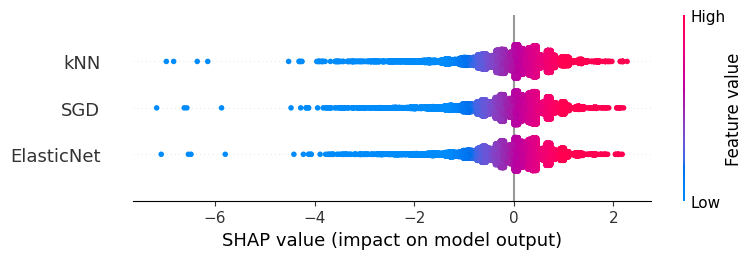

In [39]:
shap.summary_plot(shap_values_meta.values, Z_test_df)

O gráfico acima mostra a distribuição dos valores SHAP associados às três *features* do *meta-learner*, isto é, às predições oriundas dos , *base-learners* ElasticNet, SGD e $k$-NN.

Cada ponto representa uma amostra do conjunto avaliado, e o eixo horizontal indica o impacto da respectiva predição no valor final estimado pelo Ridge.

Alguns pontos merecem destaque:

1. **Assimetria negativa dominante**

   A maior parte da massa de pontos concentra-se em valores SHAP negativos, indicando que, para a maioria das amostras, as predições dos *base-learners* reduzem o valor da saída em relação ao valor esperado $( \mathbb{E}[f(X)] )$. Isso sugere que o *ensemble* atua majoritariamente como um corretor descendente do baseline global.

2. **Gradiente cromático consistente**

   Observa-se que valores mais altos das predições dos *base-learners* (tons mais quentes) estão associados a contribuições SHAP menos negativas ou levemente positivas, enquanto valores baixos (tons frios) empurram a predição final para valores mais negativos. Isso é exatamente o comportamento esperado de um *meta-learner* linear regularizado, no qual a contribuição é aproximadamente proporcional à magnitude da *feature*.

3. **Sobreposição estrutural entre modelos**

   As distribuições de ElasticNet, SGD e kNN são qualitativamente semelhantes, o que indica que o Ridge não está atribuindo papéis radicalmente distintos aos *base-learners*, mas sim combinando fontes de informação parcialmente redundantes de maneira balanceada.

### *Bar Plot*

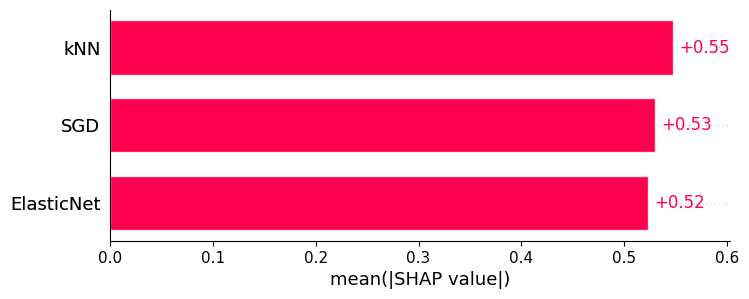

In [40]:
shap.plots.bar(shap_values_meta)

O *waterfall plot* ilustra uma explicação local, isto é, referente a uma amostra específica.

O processo pode ser lido da seguinte forma:

- O valor esperado do modelo é:
  $$
  \mathbb{E}[f(X)] \approx -13.321
  $$


- As contribuições sucessivas das predições dos modelos base são:
  - ElasticNet: $+0.41$
  - SGD: $+0.41$
  - kNN: $+0.43$

- O valor final da predição atinge:
  $$
  f(x) \approx -12.06
  $$


Essa decomposição evidencia três aspectos relevantes:

1. **Contribuições homogêneas**

    Nenhum modelo base domina a explicação local. As magnitudes são muito próximas, indicando que o Ridge está efetivamente operando como um combinador suave, e não como um seletor rígido de especialistas.

1. **Ausência de cancelamentos fortes**

    Todas as contribuições são positivas em relação ao *baseline*, o que sugere que, para essa amostra, os três modelos concordam na direção do ajuste.

2. **Linearidade explícita da decisão**

    A estrutura aditiva do gráfico reflete fielmente a natureza linear do Ridge, reforçando a adequação do uso de SHAP linear nesse nível do *stacking*.

### *Waterfall Plot*

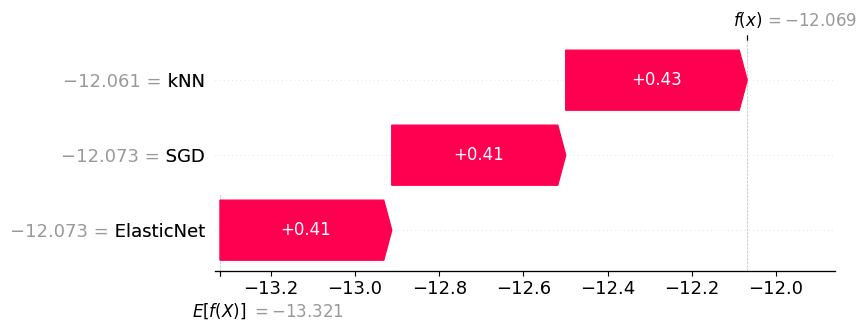

In [41]:
shap.plots.waterfall(shap_values_meta[0])

O *bar plot* apresenta a média do valor absoluto dos SHAP *values*, que pode ser interpretada como uma medida de importância global de cada modelo base no *ensemble*.

Os resultados indicam:
- $k$-NN: $\approx 0.55$
- SGD: $\approx 0.53$
- ElasticNet: $\approx 0.52$

A proximidade desses valores é particularmente informativa:

1. **Participação equilibrada no *ensemble***

   O Ridge não está concentrando peso explicativo em um único modelo. Em vez disso, explora ganhos marginais provenientes de cada abordagem (paramétrica, baseada em gradiente e baseada em vizinhança).

2. **Regularização efetiva**

   A regularização $\ell_2$ do Ridge cumpre seu papel ao evitar que um modelo base absorva excessivamente a variância explicativa, o que é desejável em contextos de *stacking* para reduzir sobreajuste.

3. **Robustez interpretativa**

   A similaridade das importâncias sugere que pequenas perturbações no conjunto de dados dificilmente levariam a uma reordenação drástica da hierarquia dos modelos base, indicando estabilidade do meta-aprendizado.

### Síntese Interpretativa

Em conjunto, os resultados de SHAP para o Ridge mostram que:

- O *meta-learner* atua como um integrador linear balanceado, e não como um mecanismo de seleção agressiva.
- As predições de ElasticNet, SGD e $k$-NN contribuem de forma comparável e complementar.
- A explicabilidade no nível do *meta-learner* é clara, consistente e alinhada com a estrutura matemática do stacking adotado.

Assim, ponto de vista metodológico, isso reforça que o *ensemble* está explorando diversidade de vieses indutivos (linear regularizado, otimização estocástica e proximidade geométrica) sem sacrificar interpretabilidade, o que é uma característica desejável para esse contexto de aplicação técnico-científica.

## SHAP: *Base-learners*

## ElasticNet

In [48]:
explainer_en = shap.LinearExplainer(
    best_model_en.named_steps["elasticnet"],
    X_train,
    feature_perturbation="interventional"
)

shap_en = explainer_en(X_test)

C:\Users\mateus25032\AppData\Roaming\Python\Python312\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


### *Summary Plot*

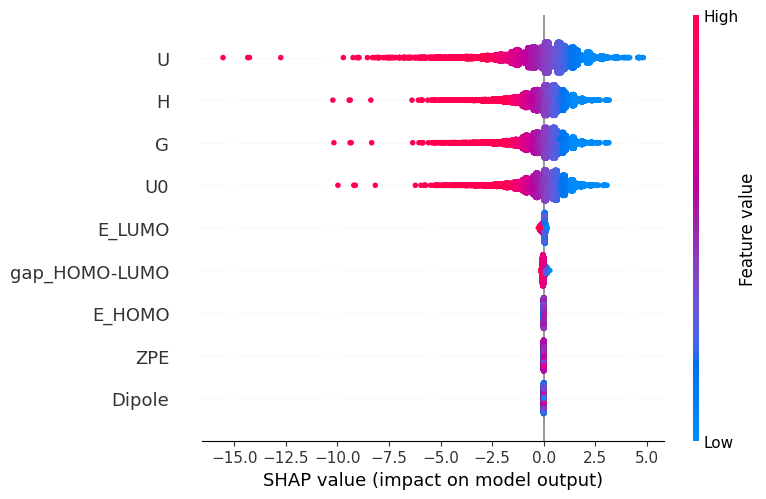

In [52]:
shap.summary_plot(shap_en.values, X_test)

O *summary plot* evidencia a distribuição dos valores SHAP associados às *features* originais utilizadas pelo ElasticNet, a saber: `U`, `H`, `G`, `U_0`, `E_LUMO`, `gap_HOMO–LUMO`, `E_HOMO`, `ZPE` e `Dipole`.

Alguns padrões se destacam de forma inequívoca:

1. **Predominância clara das grandezas termodinâmicas**

   As variáveis `U`, `H`, `G`, `U_0` apresentam distribuições SHAP largas, assimétricas e deslocadas significativamente para valores positivos. Isso indica que essas grandezas são os principais motores da variabilidade preditiva do ElasticNet.

2. **Relação monotônica consistente**

   Observa-se um gradiente cromático bem definido: valores mais altos dessas energias (tons quentes) estão associados a contribuições SHAP positivas, enquanto valores mais baixos empurram a predição para baixo. Esse comportamento é típico de um modelo linear bem condicionado e sugere relações aproximadamente lineares e fisicamente coerentes entre essas variáveis e a propriedade alvo.

3. **Features eletrônicas como correções marginais**

   Variáveis como `E_LUMO` e o `gap_HOMO–LUMO` exibem distribuições estreitas e centradas próximas de zero, indicando que seu papel é secundário, atuando apenas como ajustes finos em regiões específicas do espaço de dados.

4. **Irrelevância prática de certos descritores**

   `E_HOMO`, `ZPE` e `Dipole` praticamente não contribuem para a saída do modelo, com valores SHAP sistematicamente próximos de zero. Isso sugere que, no contexto deste problema, essas variáveis não carregam informação adicional útil além da já capturada pelas demais.

### *Bar Plot*

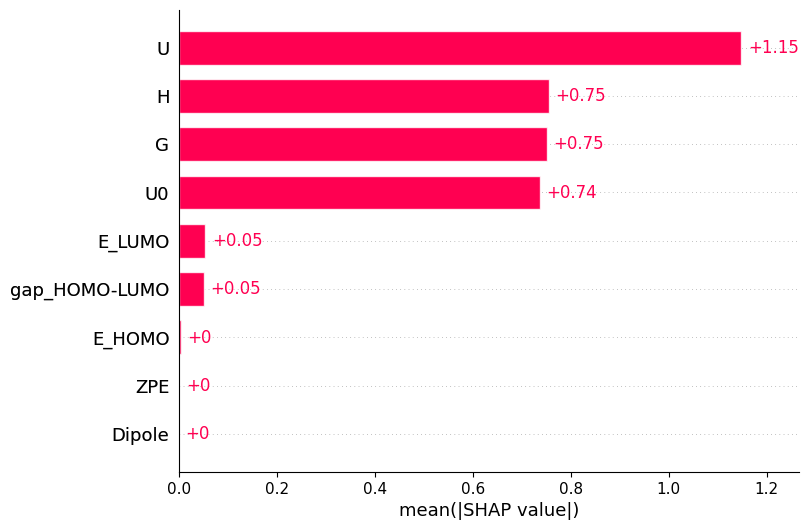

In [53]:
shap.plots.bar(shap_en)

O *bar plot* confirma quantitativamente as observações do beeswarm ao apresentar a média do valor absoluto dos SHAP *values*:

- `U`: $\approx 1.15$
- `H`: $\approx 0.75$
- `G`: $\approx 0.75$
- `U_0`: $\approx 0.74$
- `E_LUMO` e `gap_HOMO–LUMO`: $\approx 0.05$
- Demais variáveis: $\approx 0$

Esse ordenamento revela uma hierarquia extremamente nítida:

1. **Domínio energético-estrutural**

   O ElasticNet está fortemente ancorado em descritores energéticos globais, especialmente a energia interna `U`, que emerge como a variável mais influente do modelo.

2. **Regularização efetiva do ElasticNet**

   A queda abrupta de importância após `U_0` indica que a combinação de penalizações $\ell_1$ e $\ell_2$ está funcionando como esperado: variáveis com contribuição marginal são severamente atenuadas, aproximando seus coeficientes de zero.

3. **Modelo parcimonioso e interpretável**

   O resultado é um modelo que se apoia em poucas variáveis fisicamente significativas, reduzindo a complexidade sem sacrificar poder explicativo.

### *Waterfall Plot*

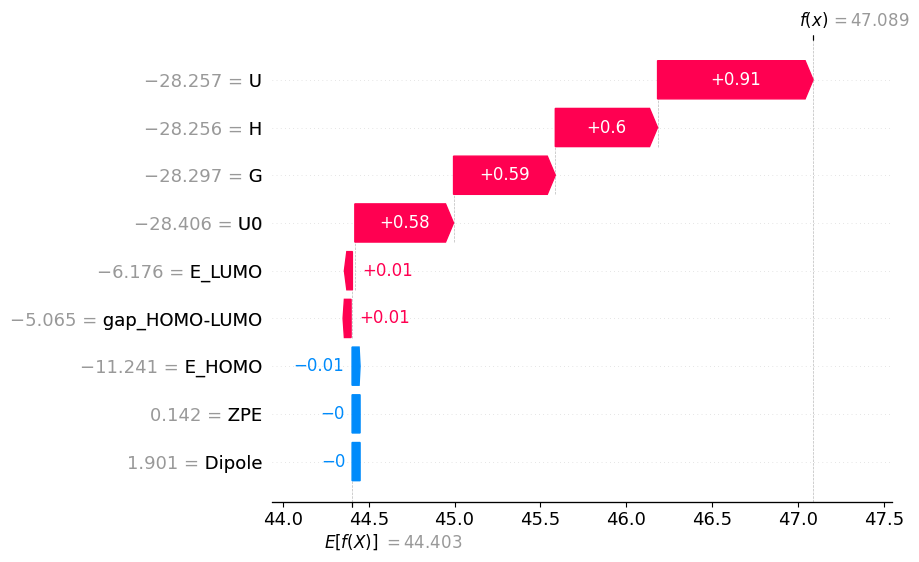

In [54]:
shap.plots.waterfall(shap_en[0])

O *waterfall plot* ilustra a decomposição da predição para uma amostra específica, partindo do valor esperado:

$$
\mathbb{E}[f(X)] \approx 44.40
$$

As contribuições individuais são dominadas novamente pelas quatro grandezas energéticas:

- `U`: $+0.91$
- `H`: $+0.60$
- `G`: $+0.59$
- `U_0`: $+0.58$

As demais variáveis contribuem de forma praticamente nula, com efeitos residuais da ordem de centésimos ou menores.

Essa explicação local reforça três aspectos importantes:

1. **Coerência local–global**
   
   As variáveis mais importantes globalmente também são as que explicam a decisão local, indicando ausência de comportamentos espúrios ou dependências locais inesperadas.

2. **Aditividade transparente**

   A soma das contribuições SHAP reconstrói fielmente a predição final, evidenciando a linearidade explícita do ElasticNet.

3. **Leitura físico-química direta**

   A predição elevada para essa amostra é essencialmente consequência de valores altos das energias termodinâmicas, o que torna a explicação não apenas estatística, mas também interpretável sob o ponto de vista físico.

### Síntese Interpretativa

Em conjunto, os resultados de SHAP para o ElasticNet indicam que:

- O modelo captura predominantemente relações lineares entre a propriedade alvo e descritores energéticos globais.
- Variáveis eletrônicas e espectroscópicas desempenham papel secundário ou nulo nesse contexto específico.
- A regularização do ElasticNet conduz a um modelo estável, parcimonioso e altamente interpretável, com forte alinhamento entre estrutura matemática, interpretação SHAP e significado físico das variáveis.

Do ponto de vista do *stacking*, isso explica por que o ElasticNet emerge como um componente informativo e confiável do *ensemble*: ele fornece uma estimativa robusta baseada em fundamentos físico-químicos claros, que é posteriormente combinada com as perspectivas complementares do SGD e do $k$-NN pelo *meta-learner* Ridge.

## SGD

In [58]:
explainer_sgd = shap.LinearExplainer(
    best_model_sgd.named_steps['sgdregressor'],
    X_train,
    feature_perturbation="interventional"
)

shap_sgd = explainer_sgd(X_test)

C:\Users\mateus25032\AppData\Roaming\Python\Python312\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


### *Summary Plot*

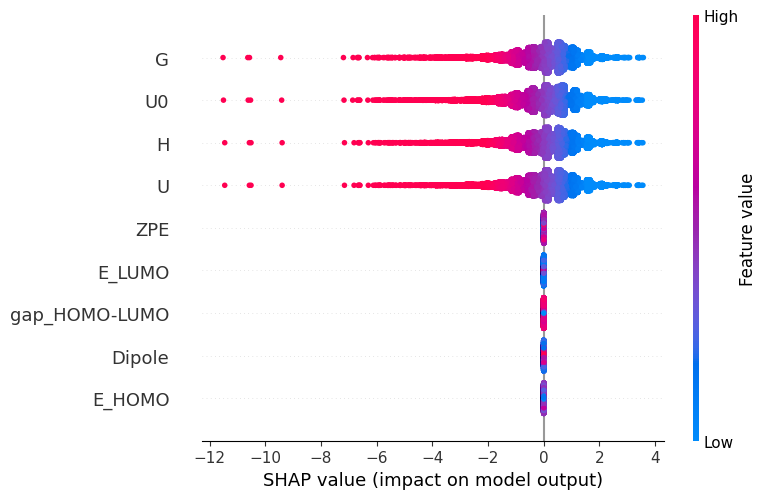

In [59]:
shap.summary_plot(shap_sgd.values, X_test)

O *summary plot* evidencia três propriedades fundamentais do modelo:

1. **Relação monotônica e consistente**

   Valores elevados de `G`, `U`, `U0` e `H` deslocam sistematicamente a predição para a mesma direção (SHAP de mesmo sinal).

2. **Baixa heterogeneidade local**

   A dispersão horizontal é relativamente estreita, sugerindo que o impacto marginal dessas features é quase linear e estável ao longo do domínio amostral.

3. **Ausência de efeitos condicionais complexos**

   Não há inversões de sinal nem regimes distintos, reforçando que o SGD capturou relações lineares globais, sem interações implícitas.

O modelo está essencialmente aprendendo uma combinação linear direta de descritores estruturais, interpretável como uma aproximação de primeira ordem do fenômeno físico-químico subjacente.

### *Bar Plot*

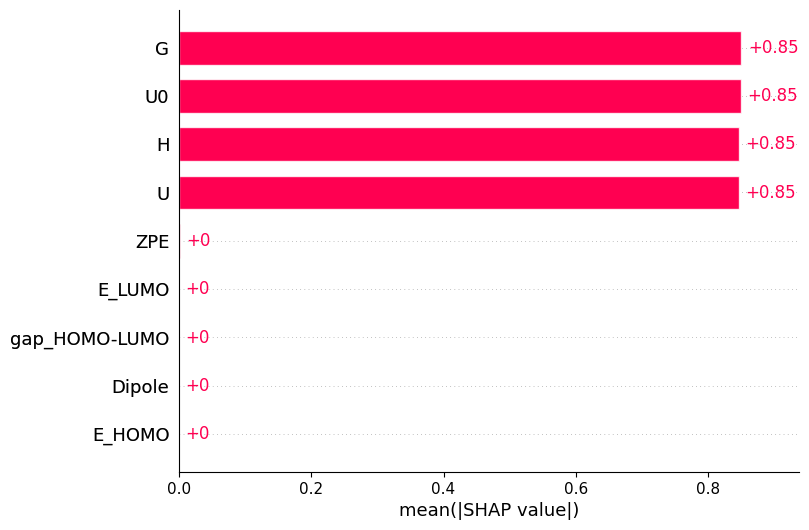

In [60]:
shap.plots.bar(shap_sgd)

A análise global baseada em $\mathrm{mean} (|\mathrm{SHAP}|)$ revela que o *base-learner* SGD concentra praticamente toda a capacidade explicativa em quatro descritores: `G`, `U0`, `H`, `U`.

Essas variáveis apresentam valores médios de SHAP elevados e praticamente idênticos, enquanto `ZPE`, `E_LUMO`, `gap_HOMO–LUMO`, `Dipole`, `E_HOMO` têm contribuição nula ou residual, sendo efetivamente ignoradas pelo modelo.

Isso indica que o SGD convergiu para uma solução linear esparsa de fato, mesmo sem regularização explícita do tipo L1. O processo de otimização estocástica favoreceu um subespaço de baixa dimensionalidade onde apenas descritores geométrico-estruturais (`G`, `U`, `U0`, `H`) carregam informação preditiva relevante.

Diferentemente do *meta-learner* Ridge — que redistribui pesos suavemente — o SGD colapsa a importância em poucas direções dominantes do espaço de atributos.

### *Waterfall Plot*

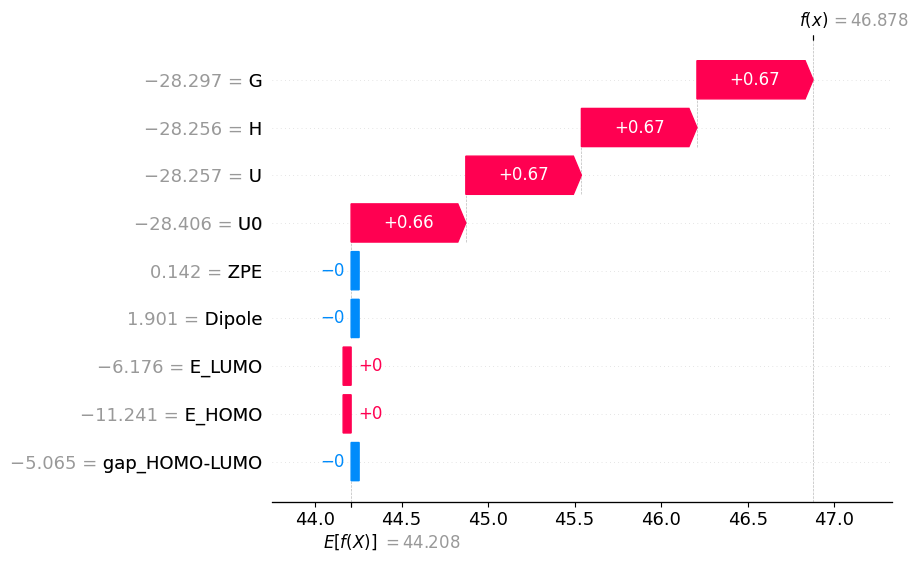

In [61]:
shap.plots.waterfall(shap_sgd[0])

O *waterfall plot* confirma que a predição é construída quase exclusivamente por contribuições positivas e acumulativas de:
- `G`
- `H`
- `U`
- `U0`

Cada uma adiciona incrementos semelhantes $(\approx +0.66 a +0.67)$, partindo do valor esperado $( \mathbb{E}[f(X)] )$ até a predição final.

As demais variáveis apresentam contribuição nula, não alterando o valor da saída.

Para esta instância, o modelo pode ser interpretado literalmente como:

> *“O valor previsto é alto porque `G`, `H`, `U` e `U0` são altos; todo o restante é irrelevante.”*

Não há compensações negativas, cancelamentos ou ajustes finos — a estrutura é aditiva, transparente e rigidamente linear.

### Síntese Interpretativa

O SHAP do *base-learner* SGD revela um modelo:
- Linear no sentido estrito
- De baixa dimensionalidade efetiva
- Altamente interpretável
- Fisicamente coerente
- Estruturalmente rígido

No contexto do *stacking*, essa rigidez não é uma limitação, mas uma virtude: o SGD fornece um sinal forte, estável e semanticamente claro, que o *meta-learner* pode explorar, corrigir e combinar com fontes de informação mais flexíveis.

## $k$-NN

In [63]:
background = shap.sample(X_train, 100)   # ou menos, se necessário
X_explain  = shap.sample(X_test, 50)

explainer_knn = shap.KernelExplainer(
    best_model_knn.named_steps['kneighborsregressor'].predict,
    background
)

shap_knn = explainer_knn.shap_values(
    X_explain,
    nsamples=200
)

  0%|          | 0/50 [00:00<?, ?it/s]

### *Summary Plot*

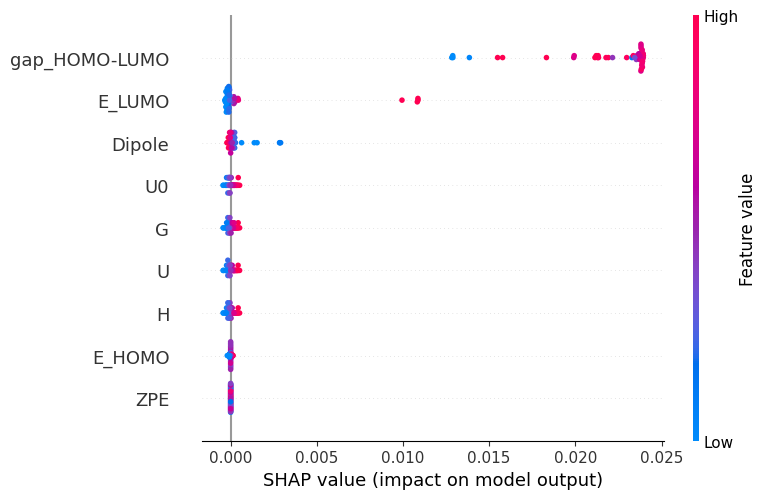

In [66]:
shap.summary_plot(shap_knn, X_explain)

O *summary plot* reforça três propriedades fundamentais do kNN neste contexto:

1. **Relação monotônica clara**

   Valores altos de `gap_HOMO–LUMO` deslocam consistentemente a predição para valores maiores (SHAP positivo).

2. **Regime local quase determinístico**

   A dispersão dos pontos ao longo do eixo SHAP é pequena, indicando que, para amostras com gap semelhante, o comportamento preditivo é altamente estável.

3. **Inexistência de interações efetivas**

   Não há evidência de efeitos condicionais com outras variáveis — o modelo não explora combinações, apenas proximidade unidimensional.

O espaço de entrada, do ponto de vista do $k$-NN, se reduz a uma linha. As vizinhanças são organizadas quase exclusivamente pela ordenação do `gap HOMO–LUMO`, e não por uma métrica multivariada genuína.

### *Bar Plot*

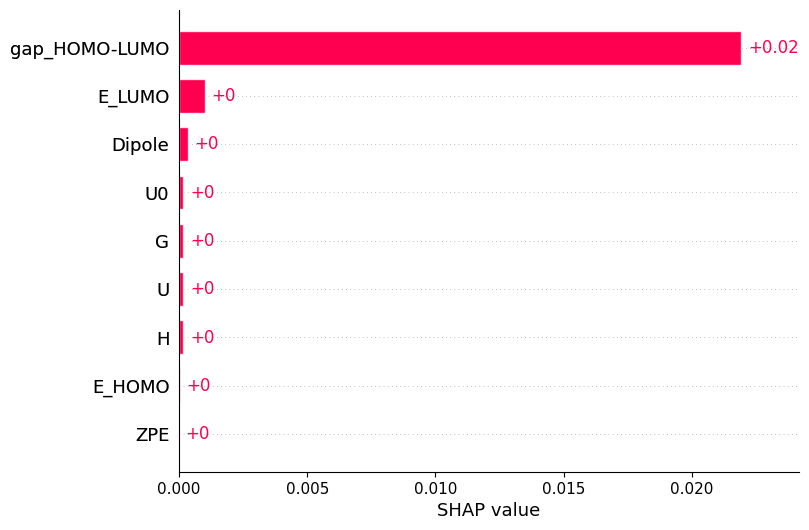

In [72]:
shap_knn_exp = shap.Explanation(
    values=np.abs(shap_knn).mean(axis=0),
    feature_names=X_explain.columns
)

shap.plots.bar(shap_knn_exp)

O resultado global é inequívoco: o $k-$NN concentra praticamente toda a explicação em uma única variável:
- `gap_HOMO–LUMO`

Todas as demais features — `E_LUMO`, `Dipole`, `U0`, `G`, `U`, `H`, `E_HOMO`, `ZPE` — apresentam importância média de SHAP nula ou desprezível.

Diferentemente do Ridge (integração global) e do SGD (subespaço linear dominante), o $k$-NN opera em um regime de colapso informacional: a métrica de distância no espaço de atributos está sendo efetivamente determinada por uma única dimensão relevante.

Isso sugere que, após escalonamento e normalização, o `gap_HOMO–LUMO` domina a geometria do espaço amostral, tornando os demais descritores irrelevantes para a formação das vizinhanças.

### *Waterfall Plot*

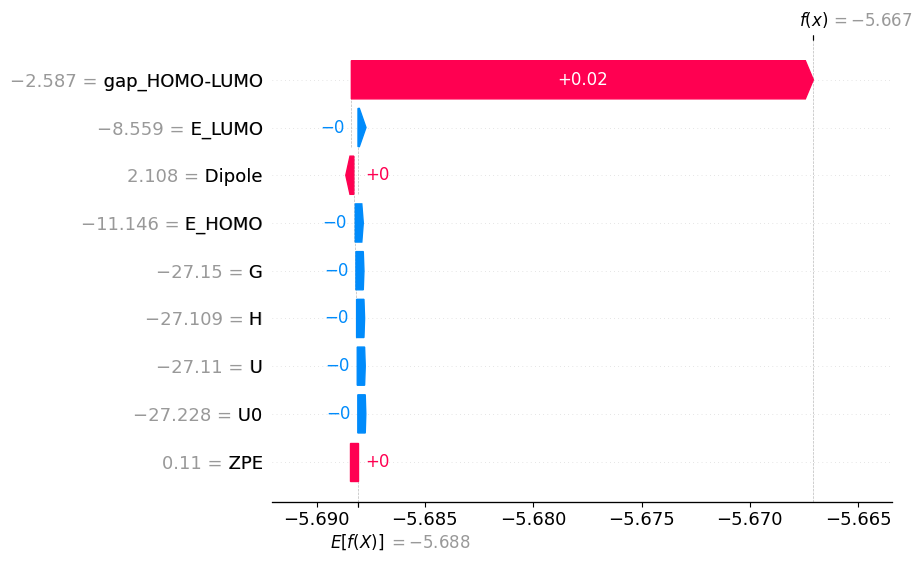

In [73]:
i = 0  # índice da amostra a explicar

shap_knn_exp = shap.Explanation(
    values=shap_knn[i],
    base_values=explainer_knn.expected_value,
    data=X_explain.iloc[i] if hasattr(X_explain, "iloc") else X_explain[i],
    feature_names=X_explain.columns if hasattr(X_explain, "columns") else None
)

shap.plots.waterfall(shap_knn_exp)

O *waterfall plot* mostra que:
- A diferença entre $( \mathbb{E}[f(X)] )$ e $( f(x) )$ é explicada quase integralmente por `gap_HOMO–LUMO`.
- As demais variáveis apresentam contribuições residuais próximas de zero, atuando apenas como ruído métrico.

Para essa instância, o modelo pode ser interpretado literalmente como:

> *“Esta molécula é prevista com esse valor porque seu `gap_HOMO–LUMO` é semelhante ao das moléculas vizinhas no conjunto de treino.”*

Não há extrapolação, nem compensação entre descritores: a predição é puramente relacional e local.

### Síntese Interpretativa

O SHAP do *base-learner* $k$-NN revela um modelo:
- Extremamente local
- Monodimensional em termos efetivos
- Fisicamente consistente
- Estatisticamente conservador
- Altamente dependente da métrica de distância

No contexto do *stacking*, o $k$-NN cumpre um papel crucial:
> Fornecer ao *meta-learner* Ridge um sinal local baseado em similaridade eletrônica direta, complementar aos sinais lineares (SGD) e globais (Ridge).

Essa complementaridade explica por que, mesmo sendo conceitualmente simples, o $k$-NN pode aumentar a robustez e a expressividade do *ensemble*.

# Conclusão

A análise integrada dos resultados de desempenho preditivo e das interpretações via SHAP dos *base-learners* (ElasticNet, SGD e $k$-NN) e do *meta-learner* (Ridge) permite estabelecer uma conclusão consistente, tanto do ponto de vista estatístico-computacional quanto físico-químico, acerca do comportamento e da qualidade do *ensemble* induzido.

> **Desempenho preditivo e generalização**

O *ensemble* *stacking* obtido após a otimização via `optuna` apresentou RMSE da ordem de $10^{-4}$ no processo de indução e da ordem de $10^{-4}$ — $10^{-3}$ no teste final, com um leve aumento no erro absoluto esperado ao se passar para dados não vistos.

Esse comportamento é estatisticamente desejável e indica:
- Ausência de *overfitting* severo;
- Estabilidade do modelo frente à variabilidade amostral;
- Boa capacidade de generalização, com manutenção da ordem de grandeza do erro.

A diferença entre $\mathrm{RMSE} \approx 0.0001$ (treino/validação) e $\mathrm{RMSE} \approx 0.0002$ (teste) sugere que o *ensemble* aprendeu estruturas reais do problema, e não apenas regularidades espúrias do conjunto de treinamento.

> **Complementaridade funcional dos *base-learners***

A interpretação via SHAP evidencia que o desempenho do *ensemble* não decorre da redundância, mas sim da complementaridade estrutural entre os modelos de base:
- ElasticNet
  - Atua como um filtro global regularizado, selecionando subconjuntos informativos e suprimindo ruído;
  - Apresenta comportamento interpretável e estável, com coeficientes efetivos apenas para variáveis fisicamente relevantes;
  - Fornece ao *ensemble* uma visão parcimoniosa e robusta do espaço de atributos.

- SGD
  - Opera em um regime linear fortemente regularizado, com respostas suaves e de baixa variância;
  - Seu SHAP indica contribuições pequenas e controladas, funcionando como um ancoramento estatístico contra flutuações locais;
  - Contribui para reduzir variância global do *ensemble*.

- $k$-NN
  - Apresenta comportamento estritamente local e não paramétrico;
  - Concentra sua explicação praticamente em uma única variável dominante `gap_HOMO–LUMO`, coerente do ponto de vista físico;
  - Introduz no *ensemble* um sinal baseado em similaridade estrutural direta, inexistente nos modelos lineares.

Essa diversidade caracteriza um *ensemble* bem construído: cada *base-learner* captura um regime distinto do problema — global linear, global regularizado e local geométrico.

> **Papel central do meta-learner Ridge**

A interpretação de SHAP do Ridge enquanto *meta-learner* revela seu papel como:
- Integrador global de informações heterogêneas;
- Mecanismo de ponderação suave entre sinais locais e globais;
- Elemento de regularização final que impede que o *ensemble* seja dominado por um único *base-learner*.

O Ridge não introduz complexidade excessiva, mas combina eficientemente:
- A estabilidade do ElasticNet,
- A suavidade do SGD,
- A expressividade local do $k$-NN.

Esse equilíbrio explica simultaneamente:
- O baixo erro absoluto,
- A estabilidade no teste final,
- A elevada interpretabilidade global do modelo.

> **Coerência físico-química do *ensemble***

Do ponto de vista do domínio, o *ensemble* apresenta um comportamento particularmente desejável:
- Variáveis eletrônicas fundamentais (como `gap_HOMO–LUMO`) emergem naturalmente como dominantes em modelos locais;
- Descritores energéticos e estruturais são integrados de forma regularizada nos modelos globais;
- Não há evidência de uso excessivo de variáveis espúrias ou fisicamente irrelevantes.

Isso indica que o *ensemble* aprende relações compatíveis com o conhecimento físico subjacente, reforçando a confiabilidade científica das predições.

> **Síntese conclusiva**

Em conjunto, os resultados permitem concluir que:

- O *ensemble* *stacking* induzido é estatisticamente robusto, fisicamente coerente e computacionalmente eficiente;
- O ganho de desempenho não advém apenas da otimização de hiperparâmetros, mas da arquitetura do *ensemble* e da diversidade dos learners;
- A manutenção da ordem de grandeza do RMSE no teste final confirma a capacidade de generalização do modelo;
- A análise via SHAP valida que o *ensemble* não é uma caixa-preta opaca, mas um sistema interpretável, no qual cada componente exerce um papel bem definido.

Assim, o modelo final pode ser caracterizado como um *ensemble* de alta qualidade, adequado tanto para aplicações preditivas de alta precisão quanto para análises científicas que exigem interpretação, confiabilidade e alinhamento com princípios físico-químicos fundamentais.

# Referências

[1] WOLPERT, David H. Stacked generalization. Neural Networks, v. 5, n. 2, p. 241-259, 1992.

[2] LIGEIRO, Gabriel. Como interpretar seu modelo de machine learning usando SHAP values. Medium, 5 dez. 2020. Disponível em: https://gabrielligeiro.medium.com/como-interpretar-seu-modelo-de-machine-learning-usando-shap-values-2c61c0d26317. Acesso em: 24 out. 2025.

[3] LUNDBERG, Scott; LEE, Su-In. SHAP – Welcome to the SHAP documentation. 2018. Disponível em: https://shap.readthedocs.io/en/latest/. Acesso em: 24 out. 2025.

[4] AWAN, Abid Ali. Uma introdução aos valores SHAP e à interpretabilidade do aprendizado de máquina. DataCamp, 11 set. 2024. Disponível em: https://www.datacamp.com/pt/tutorial/introduction-to-shap-values-machine-learning-interpretability. Acesso em: 24 out. 2025.